# Datathon 2026 - Notebook 02
## District indices & cross dataset analysis

Inputs: primary data (9 files) & secondary data (KAG, ASER).

notes:
- education districts stay separate, inheriting parent's KAG data.
- ASER comparison handles Vijayanagara by merging it into Ballari or dropping it.

## A - setup

In [1]:
import json
import re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.autolayout"] = True

### config

In [2]:
PRIMARY_DIR   = Path("Primary_Dataset")
SECONDARY_DIR = Path("Secondary_Dataset")

KAG_FILE  = Path("Secondary_Datset/KAG_2024-25_Secondary_Data_Extract.xlsx")
ASER_FILE = Path("Secondary_Datset/ASER_2024_Karnataka_Rural_Extract.xlsx")

SEED = 42

OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
PREFIX = "xds_"

CACHE = OUT / "primary_district_grade_competency.csv"

FOCUS_YEAR = "2024-25"
Q_COLS = [f"Q{i}" for i in range(1, 21)]

ZERO_OOS_SUSPECT = ["Raichuru", "Ballari", "Vijayanagara"]

### saving charts
wrapper from nb 01, changed prefix to avoid overwrites.

In [3]:
# save charts to png -- safe to re-run
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# only capture the real plt.show once, even if this cell is re-run
if not getattr(plt.show, "_is_autosaver", False):
    _show_original = plt.show

_fig_count = 0

def _slug(text, fallback="figure"):
    s = re.sub(r"[^a-z0-9]+", "_", str(text).lower()).strip("_")
    if len(s) > 44:
        s = s[:44].rsplit("_", 1)[0]
    return s or fallback

def _save_then_show(*args, **kwargs):
    global _fig_count
    fig = plt.gcf()
    axes = fig.get_axes()
    if axes:
        title = fig._suptitle.get_text() if fig._suptitle else ""
        if not title:
            title = next((a.get_title() for a in axes if a.get_title()), "")
        _fig_count += 1
        name = f"{PREFIX}{_fig_count:02d}_{_slug(title)}.png"
        try:
            fig.savefig(FIG / name, dpi=150, bbox_inches="tight", facecolor="white")
        except Exception as exc:
            print(f"could not save {name}: {exc}")
    _show_original(*args, **kwargs)

_save_then_show._is_autosaver = True
plt.show = _save_then_show
print(f"charts will be saved to {FIG}/ with the prefix {PREFIX!r}")

charts will be saved to outputs/figures/ with the prefix 'xds_'


### helpers

In [4]:
def canonicalise(name):
    return re.sub(r"[^a-z0-9]", "", str(name).lower())

def minmax(s):
    s = pd.to_numeric(s, errors="coerce")
    lo, hi = s.min(), s.max()
    if pd.isna(lo) or hi == lo:
        return pd.Series(np.nan, index=s.index)
    return (s - lo) / (hi - lo)

def wavg(frame, value_col, weight_col):
    v = pd.to_numeric(frame[value_col], errors="coerce")
    w = pd.to_numeric(frame[weight_col], errors="coerce")
    m = v.notna() & w.notna() & (w > 0)
    return np.average(v[m], weights=w[m]) if m.any() else np.nan

def scope_note(ax, text):
    ax.text(0.005, -0.16, text, transform=ax.transAxes, fontsize=8,
            color="dimgrey", va="top")

def label_points(ax, x, y, labels, size=7, alpha=0.85):
    for xi, yi, li in zip(x, y, labels):
        if pd.notna(xi) and pd.notna(yi):
            ax.annotate(li, (xi, yi), fontsize=size, alpha=alpha,
                        xytext=(3, 3), textcoords="offset points")

### primary -> KAG mapping

In [5]:
PRIMARY_TO_KAG = {
    "bagalkot": "Bagalkote",
    "ballari": "Ballari",
    "bidar": "Bidar",
    "chamarajanagara": "Chamarajanagara",
    "chikkaballapura": "Chikkaballapura",
    "chikkamagaluru": "Chikkamagaluru",
    "chitradurga": "Chitradurga",
    "dakshina kannada": "Dakshina Kannada",
    "davanagere": "Davanagere",
    "dharwad": "Dharwada",
    "gadag": "Gadag",
    "hassan": "Hassan",
    "haveri": "Haveri",
    "kalaburgi": "Kalburgi",
    "kalaburagi": "Kalburgi",
    "kodagu": "Kodagu",
    "kolar": "Kolara",
    "koppal": "Koppal",
    "mandya": "Mandya",
    "mysuru": "Mysuru",
    "raichur": "Raichuru",
    "ramanagara": "Ramanagara",
    "udupi": "Udupi",
    "vijayanagar": "Vijayanagara",
    "vijayapura": "Vijayapura",
    "yadagiri": "Yadgiri",
    "bengaluru rural": "Bengaluru (Rural)",
    #only in secondary
    "bengaluru urban": "Bengaluru (Urban)",
    "shivamogga": "Shivamogga",
    #map to parent
    "belagavi": "Belagavi",
    "belagavi chikkodi": "Belagavi",
    "chikkodi": "Belagavi",
    "tumakuru": "Tumakuru",
    "tumakuru madhugiri": "Tumakuru",
    "madhugiri": "Tumakuru",
    "uttara kannada": "Uttara Kannada",
    "uttara kannada sirsi": "Uttara Kannada",
    "uttara kannada karwar": "Uttara Kannada",
    "sirsi": "Uttara Kannada",
    "karwar": "Uttara Kannada",
}
PRIMARY_TO_KAG_CANON = {canonicalise(k): v for k, v in PRIMARY_TO_KAG.items()}

# ed districts
EDU_DISTRICT_STRINGS = {
    "belagavi chikkodi", "chikkodi",
    "tumakuru madhugiri", "madhugiri",
    "uttara kannada sirsi", "sirsi", "uttara kannada karwar", "karwar",
}
EDU_DISTRICT_CANON = {canonicalise(s) for s in EDU_DISTRICT_STRINGS}

def to_kag_name(primary_name):
    return PRIMARY_TO_KAG_CANON.get(canonicalise(primary_name), None)

print(f"{len(PRIMARY_TO_KAG)} primary spellings mapped to "
      f"{len(set(PRIMARY_TO_KAG.values()))} KAG districts")

40 primary spellings mapped to 31 KAG districts


## B - primary data -> district x grade x competency mastery

aggregate per file, then cache. item rates are student weighted.

note: `mastery_rate` is % of correct answers, not % of students who mastered it. 0 = wrong/skip.

In [6]:
YEAR_RE  = re.compile(r"(20\d{2}-\d{2})")
GRADE_RE = re.compile(r"Grade[_\s-]?(\d+)", re.I)

def read_competency_mapping(xls, sheet="Competency Mapping"):
    for h in (0, 1, 2, 3):
        try:
            m = pd.read_excel(xls, sheet, header=h)
        except Exception:
            continue
        m = m.dropna(axis=1, how="all")
        cols = {str(c).strip().lower(): c for c in m.columns}
        if "questions" in cols and "competency" in cols:
            out = pd.DataFrame({
                "question_no": m[cols["questions"]].astype(str).str.strip(),
                "question_name": m[cols.get("question name", cols["questions"])]
                                   .astype(str).str.strip(),
                "competency": m[cols["competency"]].astype(str).str.strip().str.lower(),
            }).dropna(subset=["question_no"])
            out = out[out["question_no"].str.match(r"(?i)^Q\d+$")]
            out["question_no"] = out["question_no"].str.upper()
            if len(out):
                return out, h
    raise ValueError("could not locate the Competency Mapping header row")

def build_primary_mastery(primary_dir):
    files = sorted(Path(primary_dir).rglob("*.xlsx"))
    files = [f for f in files if not f.name.startswith("~$")]
    if not files:
        raise FileNotFoundError(f"no .xlsx found under {primary_dir}")
    frames, maps = [], []
    for path in files:
        ys, gs = YEAR_RE.search(str(path)), GRADE_RE.search(path.name)
        year = ys.group(1) if ys else "unknown"
        grade = int(gs.group(1)) if gs else -1
        xls = pd.ExcelFile(path)
        ad = pd.read_excel(xls, "Assessment Data")
        ad.columns = [str(c).strip() for c in ad.columns]
        qcols = [c for c in Q_COLS if c in ad.columns]
        ad["District"] = ad["District"].astype(str).str.strip().str.lower()
        for c in qcols:
            ad[c] = pd.to_numeric(ad[c], errors="coerce")

        g = ad.groupby("District", observed=True)
        n = g.size().rename("n_students")
        rates = g[qcols].mean()
        tidy = (rates.stack().rename("item_rate").reset_index()
                     .rename(columns={"level_1": "question_no"}))
        tidy = tidy.merge(n, on="District")

        mapping, hrow = read_competency_mapping(xls)
        mapping["Year"], mapping["Grade"] = year, grade
        maps.append(mapping)

        tidy = tidy.merge(mapping[["question_no", "competency", "question_name"]],
                          on="question_no", how="left")
        unmapped = tidy["competency"].isna().sum()
        tidy["Year"], tidy["Grade"] = year, grade
        tidy["source_file"] = path.name
        frames.append(tidy)
        print(f"  {path.name:36s} {year} G{grade}  "
              f"{len(ad):>7,} rows  {ad['District'].nunique():>2} districts  "
              f"hdr={hrow}  unmapped={unmapped}")

    items = pd.concat(frames, ignore_index=True)
    all_maps = pd.concat(maps, ignore_index=True)

    mastery = (items.dropna(subset=["competency"])
                    .groupby(["Year", "Grade", "District", "competency"],
                             observed=True)
                    .apply(lambda d: pd.Series({
                        "mastery_rate": wavg(d, "item_rate", "n_students"),
                        "n_students": d["n_students"].max(),
                        "n_items": d["question_no"].nunique()}))
                    .reset_index())
    return mastery, items, all_maps

In [7]:
if CACHE.exists():
    mastery = pd.read_csv(CACHE)
    print(f"loaded cached mastery table: {CACHE}  ({len(mastery):,} rows)")
    items = all_maps = None
else:
    print("building from Excel (this is the slow step) ...")
    mastery, items, all_maps = build_primary_mastery(PRIMARY_DIR)
    mastery.to_csv(CACHE, index=False)
    print(f"\ncached -> {CACHE}  ({len(mastery):,} rows)")

mastery["District"] = mastery["District"].astype(str).str.strip().str.lower()
display(mastery.head())
print("\nyears:", sorted(mastery["Year"].unique()),
      "| grades:", sorted(mastery["Grade"].unique()),
      "| districts:", mastery["District"].nunique())

loaded cached mastery table: outputs/primary_district_grade_competency.csv  (2,348 rows)


,Year,Grade,District,competency,mastery_rate,n_students,n_items
0,2022-23,4,bagalkot,addition,0.718,1262.000,2.000
1,2022-23,4,bagalkot,division,0.564,1262.000,3.000
2,2022-23,4,bagalkot,fraction,0.530,1262.000,1.000
3,2022-23,4,bagalkot,measurement,0.661,1262.000,3.000
4,2022-23,4,bagalkot,multiplication,0.624,1262.000,3.000



years: ['2022-23', '2023-24', '2024-25'] | grades: [np.int64(4), np.int64(5), np.int64(6)] | districts: 31


### B0 - district coverage

districts change year over year, so trends reflect who was measured. using FOCUS_YEAR for cross section. mastery_all_years is just a check.

In [8]:
cov_year = (mastery.groupby("Year")["District"].nunique().rename("districts")
            .to_frame())
cov_year["students"] = mastery.groupby(["Year", "Grade", "District"])["n_students"].max().groupby("Year").sum()
display(cov_year)

by_year = {y: set(g["District"]) for y, g in mastery.groupby("Year")}
all_d = set().union(*by_year.values())
common = set.intersection(*by_year.values())
print(f"districts in EVERY year: {len(common)} of {len(all_d)}")
for y, s_ in by_year.items():
    missing = sorted(all_d - s_)
    print(f"  {y}: {len(s_)} districts" + (f"  MISSING {missing}" if missing else ""))
print("any statewide trend across years must either use the common set only, or say plainly that the district mix changed.")

,districts,students
Year,,
2022-23,30,312702.000
2023-24,28,470857.000
2024-25,28,595528.000


districts in EVERY year: 27 of 31
  2022-23: 30 districts  MISSING ['chikkamagaluru']
  2023-24: 28 districts  MISSING ['dakshina kannada', 'udupi', 'uttara kannada sirsi']
  2024-25: 28 districts  MISSING ['dakshina kannada', 'udupi', 'uttara kannada sirsi']
any statewide trend across years must either use the common set only, or say plainly that the district mix changed.


### B1 - shared core & district mastery

only using shared competencies across all years/grades for fairness.
district mastery = simple average of shared core mastery in focus year.

In [9]:
present = (mastery.assign(file=lambda d: d["Year"] + " G" + d["Grade"].astype(str))
                  .pivot_table(index="competency", columns="file",
                               values="mastery_rate", aggfunc="size"))
CORE = sorted(present.index[present.notna().all(axis=1)])
print(f"shared core ({len(CORE)}): {CORE}")
print("per file competency counts:")
display(present.notna().sum().rename("competencies").to_frame().T)

core = mastery[mastery["competency"].isin(CORE)].copy()

def district_mastery(frame, label):
    return (frame.groupby("District", observed=True)
                 .apply(lambda d: pd.Series({
                     label: d["mastery_rate"].mean(),
                     f"{label}_wtd": wavg(d, "mastery_rate", "n_students")}))
                 .reset_index())

focus = core[core["Year"] == FOCUS_YEAR]
if focus.empty:
    print(f"!! no rows for FOCUS_YEAR={FOCUS_YEAR}; falling back to all years")
    focus = core

prim = district_mastery(focus, "mastery")
prim = prim.merge(district_mastery(core, "mastery_all_years")
                  .drop(columns=["mastery_all_years_wtd"]), on="District")
# take 1 n_students per grade before summing
per_grade = focus.groupby(["District", "Grade"], observed=True)["n_students"].max()
prim["n_students"] = (per_grade.groupby("District").sum()
                               .reindex(prim["District"]).values)
prim = prim.sort_values("mastery", ascending=False).reset_index(drop=True)
print(f"\n{len(prim)} primary district strings, focus year = {FOCUS_YEAR}")
print(f"children assessed in {FOCUS_YEAR}: {int(prim['n_students'].sum()):,} "
      f"(each counted once, not once per competency)")
display(prim.head(10))

shared core (7): ['addition', 'division', 'measurement', 'multiplication', 'number sense', 'shapes', 'subtraction']
per file competency counts:


file,2022-23 G4,2022-23 G5,2022-23 G6,2023-24 G4,2023-24 G5,2023-24 G6,2024-25 G4,2024-25 G5,2024-25 G6
competencies,9,9,8,10,10,9,8,9,10



28 primary district strings, focus year = 2024-25
children assessed in 2024-25: 595,528 (each counted once, not once per competency)


,District,mastery,mastery_wtd,mastery_all_years,n_students
0,tumakuru,0.638,0.642,0.664,18298.000
1,belagavi,0.630,0.632,0.674,30827.000
2,bengaluru rural,0.616,0.620,0.608,8821.000
3,chikkamagaluru,0.607,0.612,0.585,14100.000
4,hassan,0.603,0.607,0.606,20228.000
5,dharwad,0.603,0.605,0.623,25046.000
6,vijayapura,0.587,0.590,0.611,44667.000
7,bagalkot,0.587,0.589,0.606,34676.000
8,belagavi chikkodi,0.584,0.585,0.629,35795.000
9,haveri,0.579,0.580,0.608,29072.000


#### grade band mastery for ASER

ASER has subtraction for G3-5 and division for G6-8. cutting primary data the same way (G4-5 subtraction, G6 division) for fairness.

In [10]:
def band_mastery(comp, grades, label):
    sub = core[(core["competency"] == comp) &
               (core["Grade"].isin(grades)) &
               (core["Year"] == FOCUS_YEAR)]
    if sub.empty:
        print(f"  !! no rows for {comp} in grades {grades} — skipping {label}")
        return pd.DataFrame(columns=["District", label])
    out = (sub.groupby("District", observed=True)
              .apply(lambda d: wavg(d, "mastery_rate", "n_students"))
              .rename(label).reset_index())
    print(f"  {label:22s} {comp:14s} grades {grades}  n={len(out)}")
    return out

print("grade band measures:")
prim = prim.merge(band_mastery("subtraction", [4, 5], "subtraction_g45"),
                  on="District", how="left")
prim = prim.merge(band_mastery("division", [6], "division_g6"),
                  on="District", how="left")
display(prim.head())

grade band measures:
  subtraction_g45        subtraction    grades [4, 5]  n=28
  division_g6            division       grades [6]  n=28


,District,mastery,mastery_wtd,mastery_all_years,n_students,subtraction_g45,division_g6
0,tumakuru,0.638,0.642,0.664,18298.000,0.634,0.424
1,belagavi,0.630,0.632,0.674,30827.000,0.613,0.502
2,bengaluru rural,0.616,0.620,0.608,8821.000,0.607,0.412
3,chikkamagaluru,0.607,0.612,0.585,14100.000,0.588,0.420
4,hassan,0.603,0.607,0.606,20228.000,0.588,0.423


## C - secondary datasets

workbooks have titles/blank rows before headers -> use header=3. drop total/note rows by name.

In [11]:
DROP_ROW_PREFIXES = ("total", "match check", "note", "state", "karnataka", "district")

def read_extract_sheet(path, sheet, header=3):
    df = pd.read_excel(path, sheet, header=header)
    df = df.dropna(axis=1, how="all")
    first = df.columns[0]
    df[first] = df[first].astype(str).str.strip()
    keep = ~df[first].str.lower().str.startswith(DROP_ROW_PREFIXES)
    keep &= df[first].notna() & (df[first].str.lower() != "nan") & (df[first] != "")
    df = df.loc[keep].copy()
    for c in df.columns[1:]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df.rename(columns={first: "District"}).reset_index(drop=True)

roads   = read_extract_sheet(KAG_FILE, "9.3a Rural Roads")
telecom = read_extract_sheet(KAG_FILE, "9.4 Internet & Telecom")
lp      = read_extract_sheet(KAG_FILE, "10.3a Lower Primary")
oos     = read_extract_sheet(KAG_FILE, "10.8 OutOfSchool & Dropout")

for name, d in [("roads", roads), ("telecom", telecom),
                ("lower primary", lp), ("out of school", oos)]:
    print(f"{name:16s} {d.shape[0]:>3} districts  {list(d.columns[1:])}")

roads             31 districts  ['Total No. of Habitations', 'No. of Habitations with All-Weather Road Access', '% Habitations with All-Weather Road Access']
telecom           31 districts  ['Post Offices', 'Telephone Exchanges', 'Telephone/Mobile Phones', 'Mobile Phone Connections', 'Internet Connections']
lower primary     31 districts  ['No. of Govt Schools', 'Total Enrollment of Boys', 'Total Enrollment of Girls', 'Total']
out of school     31 districts  ['Enrolled Boys (6-14)', 'Enrolled Girls (6-14)', 'Enrolled Total (6-14)', 'Out-of-School Boys', 'Out-of-School Girls', 'Out-of-School Total', 'Dropout Ratio (%, source)']


In [12]:
aser = read_extract_sheet(ASER_FILE, "District Estimates 2024")
cross = pd.read_excel(ASER_FILE, "District Name Crosswalk", header=3).dropna()
cross.columns = ["aser_name", "kag_name"]
cross = cross[~cross["aser_name"].str.lower().str.startswith(("use this", "(not"))]
divmap = pd.read_excel(ASER_FILE, "Divisions - District Mapping", header=3).dropna()
divmap.columns = ["Division", "aser_name"]

ASER_TO_KAG = dict(zip(cross["aser_name"], cross["kag_name"]))
aser["kag_name"] = aser["District"].map(ASER_TO_KAG).fillna(aser["District"])
aser = aser.merge(divmap, left_on="District", right_on="aser_name", how="left") \
           .drop(columns=["aser_name"])

print(f"ASER: {len(aser)} districts, {aser['Division'].nunique()} divisions")
print("unmapped ASER names:",
      sorted(set(aser.loc[~aser['District'].isin(ASER_TO_KAG), 'District'])) or "none")
display(aser.head(3))

ASER: 30 districts, 4 divisions
unmapped ASER names: none


,District,% Enrolled in Govt School (6-14),% Not Enrolled in School (6-14),% Can Read Std II Text (Std III-V),% Can Do Subtraction (Std III-V),% Can Read Std II Text (Std VI-VIII),% Can Do Division (Std VI-VIII),kag_name,Division
0,Bagalkot,72.800,0.500,20.800,39.300,57.500,46.600,Bagalkote,Belgaum
1,Belgaum,76.400,0.100,19.100,29.400,36.800,24.800,Belagavi,Belgaum
2,Bellary,70.600,0.700,16.900,22.400,35.900,19.100,Ballari,Kalaburagi


### C1 - exclusions

checked source PDFs, these are data issues:
1. internet connections data is bad (koppal ratio >1, etc). using mobile penetration instead.
2. dropout ratio duplicates out of school rate. dropping to avoid double counting.
3. 3 districts claim 0 out of school kids. setting to NaN.

In [13]:
tel = telecom.copy()
tel["internet_over_mobile"] = tel["Internet Connections"] / tel["Mobile Phone Connections"]
flags = tel.loc[(tel["internet_over_mobile"] > 0.5) |
                (tel["Internet Connections"] == tel["Telephone/Mobile Phones"]),
                ["District", "Telephone/Mobile Phones", "Mobile Phone Connections",
                 "Internet Connections", "internet_over_mobile"]]
print("districts failing the internet plausibility check:")
display(flags.sort_values("internet_over_mobile", ascending=False))

chk = oos.copy()
chk["computed_oos_rate"] = (chk["Out-of-School Total"] /
                            (chk["Out-of-School Total"] + chk["Enrolled Total (6-14)"]) * 100)
r = chk[["computed_oos_rate", "Dropout Ratio (%, source)"]].corr().iloc[0, 1]
print(f"\ncorr(computed out of school rate, published dropout ratio) = {r:.4f} "
      f"-> {'same thing, use one only' if r > 0.99 else 'distinct'}")
print("zero out of school districts:",
      sorted(chk.loc[chk['Out-of-School Total'] == 0, 'District']))

districts failing the internet plausibility check:


,District,Telephone/Mobile Phones,Mobile Phone Connections,Internet Connections,internet_over_mobile
19,Bengaluru (Urban),274524,145208,1190604,8.199
6,Koppal,1964,90870,92834,1.022
24,Kodagu,10244,152763,10244,0.067
26,Chamarajanagara,2427,46762,2427,0.052
22,Hassan,5305,167557,5305,0.032
27,Chikkaballapura,2829,115527,2829,0.024



corr(computed out of school rate, published dropout ratio) = 0.9998 -> same thing, use one only
zero out of school districts: ['Ballari', 'Raichuru', 'Vijayanagara']


## D - matching names & join audit

audit table maps primary districts to parent revenue districts. no fuzzy matching.

In [14]:
kag_names   = set(roads["District"])
aser_kagset = set(aser["kag_name"])

audit = pd.DataFrame({"primary_district": sorted(prim["District"].unique())})
audit["parent_district"] = audit["primary_district"].map(to_kag_name)
audit["is_education_district"] = audit["primary_district"].apply(
    lambda s: canonicalise(s) in EDU_DISTRICT_CANON)
audit["in_KAG"]  = audit["parent_district"].isin(kag_names)
audit["in_ASER"] = audit["parent_district"].isin(aser_kagset)

# parent with 1 ed district
_parent_n = audit.groupby("parent_district")["primary_district"].nunique()
audit["partial_coverage"] = (audit["is_education_district"] &
                             audit["parent_district"].map(_parent_n).eq(1))
audit = audit.merge(prim[["District", "n_students", "mastery"]],
                    left_on="primary_district", right_on="District",
                    how="left").drop(columns="District")

unmapped = audit.loc[audit["parent_district"].isna(), "primary_district"].tolist()
print("unmapped primary district strings (add to PRIMARY_TO_KAG):")
print("  ", unmapped or "none")

print("\npartial coverage - only one of the parent's education districts reported:")
print("  ", audit.loc[audit['partial_coverage'], 'primary_district'].tolist() or "none")

print("\nKAG districts with no primary data:")
print("  ", sorted(kag_names - set(audit['parent_district'].dropna())) or "none")
print("KAG districts with no ASER row:")
print("  ", sorted(kag_names - aser_kagset) or "none")

display(audit)

unmapped primary district strings (add to PRIMARY_TO_KAG):
   none

partial coverage - only one of the parent's education districts reported:
   none

KAG districts with no primary data:
   ['Bengaluru (Urban)', 'Dakshina Kannada', 'Shivamogga', 'Udupi', 'Uttara Kannada']
KAG districts with no ASER row:
   ['Vijayanagara']


,primary_district,parent_district,is_education_district,in_KAG,in_ASER,partial_coverage,n_students,mastery
0,bagalkot,Bagalkote,False,True,True,False,34676.000,0.587
1,ballari,Ballari,False,True,True,False,18779.000,0.362
2,belagavi,Belagavi,False,True,True,False,30827.000,0.630
3,belagavi chikkodi,Belagavi,True,True,True,False,35795.000,0.584
4,bengaluru rural,Bengaluru (Rural),False,True,True,False,8821.000,0.616
5,bidar,Bidar,False,True,True,False,14676.000,0.438
6,chamarajanagara,Chamarajanagara,False,True,True,False,11067.000,0.487
7,chikkaballapura,Chikkaballapura,False,True,True,False,14272.000,0.472
8,chikkamagaluru,Chikkamagaluru,False,True,True,False,14100.000,0.607
9,chitradurga,Chitradurga,False,True,True,False,29415.000,0.406


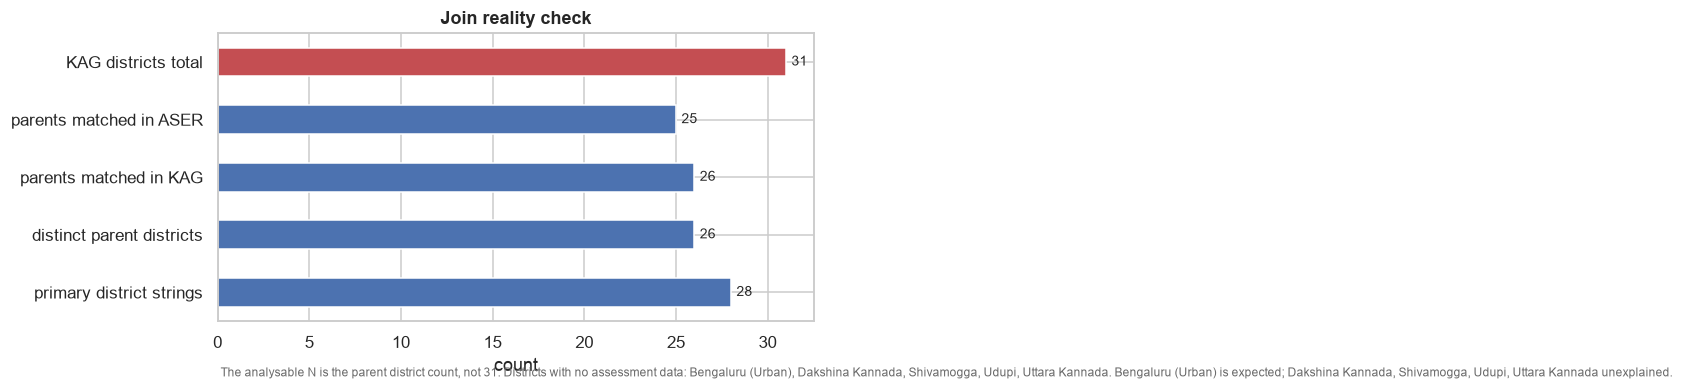

In [15]:
fig, ax = plt.subplots(figsize=(7, 3.4))
counts = pd.Series({
    "primary district strings": len(audit),
    "distinct parent districts": audit["parent_district"].nunique(),
    "parents matched in KAG": audit.loc[audit["in_KAG"], "parent_district"].nunique(),
    "parents matched in ASER": audit.loc[audit["in_ASER"], "parent_district"].nunique(),
    "KAG districts total": len(kag_names),
})
counts.plot(kind="barh", ax=ax, color=["#4c72b0"] * 4 + ["#c44e52"])
for i, v in enumerate(counts):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=9)
ax.set_title("Join reality check")
ax.set_xlabel("count")
missing_kag = sorted(kag_names - set(audit["parent_district"].dropna()))
expected_missing = {"Bengaluru (Urban)"}  # rural contest, so this one's fine
unexplained = [d for d in missing_kag if d not in expected_missing]
scope_note(ax, f"The analysable N is the parent district count, not {len(kag_names)}. "
               f"Districts with no assessment data: "
               f"{', '.join(missing_kag) if missing_kag else 'none'}. "
               + (f"Bengaluru (Urban) is expected; "
                  f"{', '.join(unexplained)} unexplained." if unexplained else ""))
plt.show()

## E - The two indices

Both built at district level from KAG 2024-25, equal weights (a convention, not a
finding). Each component is min max scaled across districts, so these are relative
positions within Karnataka, not absolute levels.

**Infrastructure Access**
- % habitations with all weather road access (9.3a)
- mobile connections per 1,000 enrolled children 6-14 (9.4 / 10.8) - note the
  denominator is *enrolled* kids, not all kids, so a district with fewer children
  scores a bit higher for the same connectivity. That's why G3 also checks road
  access on its own.
- internet excluded, see C1

**Education Access**
- out of school rate, inverted (10.8; `NaN` for the three zero reporting districts)
- gender parity in enrolment: `1 - |girls/boys - 1|` (10.3a)
- ~~govt schools per 1,000 students~~ - dropped, see below

Left out on purpose: ASER outcomes (they're what's being explained, not a predictor)
and % enrolled in govt school (that's composition, not quality). Ratios also aren't
mixed across the different KAG school tables (10.3a / 10.4a / 10.5a / 10.8) - they
cover different school universes and combining them gives nonsense numbers.

#### Why the schools ratio got dropped

It's the same thing as students per school, inverted - and students per school on
table 10.3a is unusable: it ranges from about 15 to about 296 students per school,
a twentyfold spread that looks like a column mismatch in the source, not real class
sizes (Bengaluru Rural comes out around 17, Gadag around 296). Not believable, so a
component built on it isn't either.

It's kept around as `education_index_legacy` so the effect is visible, but the
two component index is what's used everywhere else. If a correlation only holds with
the broken component in, that's the bug talking, not a finding - G3 checks exactly
that.

One more caveat: the mobile component uses a *child* denominator, so it's partly
demographic rather than purely infrastructure. Road access doesn't have that problem,
hence checking it separately in G3.

In [16]:
comp = roads[["District", "% Habitations with All-Weather Road Access"]].rename(
    columns={"% Habitations with All-Weather Road Access": "road_access_pct"})

comp = comp.merge(telecom[["District", "Mobile Phone Connections"]], on="District")
comp = comp.merge(oos[["District", "Enrolled Total (6-14)", "Enrolled Boys (6-14)",
                       "Enrolled Girls (6-14)", "Out-of-School Total"]], on="District")
comp = comp.merge(lp[["District", "No. of Govt Schools", "Total Enrollment of Boys",
                      "Total Enrollment of Girls", "Total"]], on="District")

# infrastructure components
comp["mobile_per_1000_children"] = (comp["Mobile Phone Connections"] /
                                    comp["Enrolled Total (6-14)"] * 1000)

# education components
comp["oos_rate_pct"] = (comp["Out-of-School Total"] /
                        (comp["Out-of-School Total"] + comp["Enrolled Total (6-14)"]) * 100)
comp.loc[comp["District"].isin(ZERO_OOS_SUSPECT), "oos_rate_pct"] = np.nan

comp["gender_parity"] = 1 - (comp["Total Enrollment of Girls"] /
                             comp["Total Enrollment of Boys"] - 1).abs()
comp["govt_schools_per_1000_students"] = (comp["No. of Govt Schools"] /
                                          comp["Total"] * 1000)

INFRA_COMPONENTS = {"road_access_pct": +1, "mobile_per_1000_children": +1}
EDU_COMPONENTS   = {"oos_rate_pct": -1, "gender_parity": +1}
EDU_LEGACY       = {**EDU_COMPONENTS, "govt_schools_per_1000_students": +1}

comp["students_per_school_10_3a"] = comp["Total"] / comp["No. of Govt Schools"]

for c, sign in {**INFRA_COMPONENTS, **EDU_LEGACY}.items():
    comp[f"z_{c}"] = minmax(comp[c] * sign)

comp["infrastructure_index"]   = comp[[f"z_{c}" for c in INFRA_COMPONENTS]].mean(axis=1)
comp["education_index"]        = comp[[f"z_{c}" for c in EDU_COMPONENTS]].mean(axis=1)
comp["education_index_legacy"] = comp[[f"z_{c}" for c in EDU_LEGACY]].mean(axis=1)
comp["edu_components_used"]    = comp[[f"z_{c}" for c in EDU_COMPONENTS]].notna().sum(axis=1)

print("students per school from table 10.3a - why the schools component is dropped:")
print(comp["students_per_school_10_3a"].describe()[["min", "50%", "max"]].to_string())

idx = comp[["District", "road_access_pct", "mobile_per_1000_children",
            "oos_rate_pct", "gender_parity", "govt_schools_per_1000_students",
            "students_per_school_10_3a", "infrastructure_index", "education_index",
            "education_index_legacy", "edu_components_used"]].copy()
display(idx.sort_values("infrastructure_index", ascending=False).head(10))
print(f"\ndistricts with a reduced Education Access index (zero OOS excluded): "
      f"{sorted(idx.loc[idx['edu_components_used'] < 3, 'District'])}")

students per school from table 10.3a - why the schools component is dropped:
min    14.986
50%    48.258
max   296.262


,District,road_access_pct,mobile_per_1000_children,oos_rate_pct,gender_parity,govt_schools_per_1000_students,students_per_school_10_3a,infrastructure_index,education_index,education_index_legacy,edu_components_used
14,Shivamogga,84.820,2332.561,0.054,0.988,13.283,75.284,0.784,0.927,0.670,2
24,Kodagu,75.000,2766.093,0.025,0.966,33.358,29.978,0.778,0.889,0.750,2
22,Hassan,100.000,1025.943,0.049,0.967,30.453,32.837,0.675,0.873,0.725,2
10,Haveri,97.850,1006.370,0.064,0.925,5.475,182.638,0.652,0.748,0.510,2
27,Chikkaballapura,99.470,780.699,0.057,0.935,20.722,48.258,0.624,0.779,0.611,2
11,Ballari,100.000,687.045,NaN,0.868,3.551,281.604,0.611,0.284,0.144,1
7,Gadag,100.000,646.549,0.196,0.947,3.375,296.262,0.604,0.701,0.467,2
25,Mysuru,100.000,611.600,0.043,0.958,12.935,77.310,0.597,0.853,0.619,2
8,Dharwada,99.710,616.238,0.039,0.816,23.962,41.733,0.595,0.470,0.421,2
15,Udupi,87.610,1148.314,0.059,0.928,50.249,19.901,0.588,0.759,0.753,2



districts with a reduced Education Access index (zero OOS excluded): ['Bagalkote', 'Ballari', 'Belagavi', 'Bengaluru (Rural)', 'Bengaluru (Urban)', 'Bidar', 'Chamarajanagara', 'Chikkaballapura', 'Chikkamagaluru', 'Chitradurga', 'Dakshina Kannada', 'Davanagere', 'Dharwada', 'Gadag', 'Hassan', 'Haveri', 'Kalburgi', 'Kodagu', 'Kolara', 'Koppal', 'Mandya', 'Mysuru', 'Raichuru', 'Ramanagara', 'Shivamogga', 'Tumakuru', 'Udupi', 'Uttara Kannada', 'Vijayanagara', 'Vijayapura', 'Yadgiri']


#### Are the reduced index districts comparable?

Ballari, Raichuru and Vijayanagara report zero out of school children, so their
Education Access index only averages one component instead of two - not really the
same measurement as everyone else's. Below rebuilds the ranking with those three
dropped and checks how much it moves, so the report can say which version it's
quoting.

In [17]:
reduced = idx.loc[idx["edu_components_used"] < len(EDU_COMPONENTS), "District"].tolist()
print("districts on a reduced Education Access index:", reduced or "none")

if reduced:
    n_left = int(idx.loc[idx["District"].isin(reduced), "edu_components_used"].min())
    print(f"\neach of these is built from {n_left} of {len(EDU_COMPONENTS)} components.")
    if n_left <= 1:
        print("a one component index is really just that one variable renamed - "
              "keep these out of the main chart or mark them clearly.")
    display(idx[idx["District"].isin(reduced)][
        ["District", "education_index", "edu_components_used", "oos_rate_pct",
         "gender_parity"]])
    print("dropping them doesn't reorder anyone else, so state which version "
          "of the index is being quoted in the report.")

districts on a reduced Education Access index: ['Raichuru', 'Ballari', 'Vijayanagara']

each of these is built from 1 of 2 components.
a one component index is really just that one variable renamed - keep these out of the main chart or mark them clearly.


,District,education_index,edu_components_used,oos_rate_pct,gender_parity
5,Raichuru,0.638,1,NaN,0.933
11,Ballari,0.284,1,NaN,0.868
30,Vijayanagara,0.235,1,NaN,0.859


dropping them doesn't reorder anyone else, so state which version of the index is being quoted in the report.


### E1 - what the indices look like

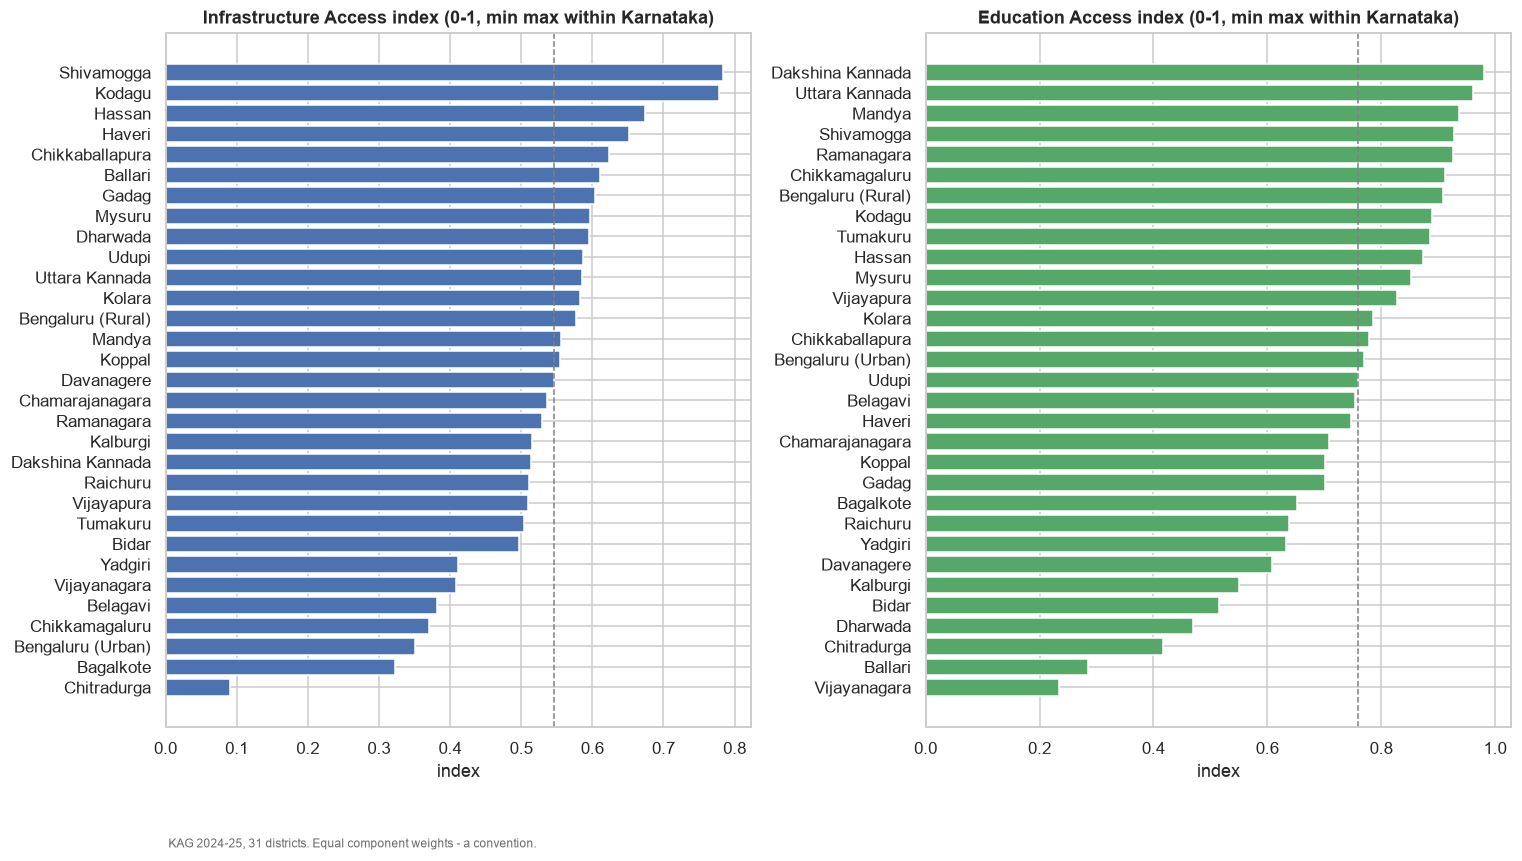

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=False)
for ax, col, title, colour in [
    (axes[0], "infrastructure_index", "Infrastructure Access", "#4c72b0"),
    (axes[1], "education_index", "Education Access", "#55a868")]:
    d = idx.sort_values(col)
    ax.barh(d["District"], d[col], color=colour)
    ax.set_title(f"{title} index (0-1, min max within Karnataka)")
    ax.set_xlabel("index")
    ax.axvline(d[col].median(), color="grey", ls="--", lw=1)
scope_note(axes[0], "KAG 2024-25, 31 districts. Equal component weights - a convention.")
plt.show()

### E2 - sensitivity check

If dropping a component reshuffled the whole ranking, the index would mostly be
measuring the weighting scheme rather than the districts. Spearman rho between the
full index and each leave one component out version checks that.

Since both indices only have two components now, dropping one just leaves the other,
so a moderate rho here is partly structural - still worth being upfront about it: on
the real numbers the infrastructure ones land around 0.5-0.6, meaning the ranking
really does depend on which component you keep. Worth saying in the report rather
than calling the index robust.

The last row compares the two component Education Access index against the old
three component version that included the broken schools ratio - that's the one that
matters most.

,index,component dropped,spearman vs full index
0,infrastructure_index,road_access_pct,0.599
1,infrastructure_index,mobile_per_1000_children,0.511
2,education_index,oos_rate_pct,0.773
3,education_index,gender_parity,0.523
4,education_index,(legacy 3-component),0.896


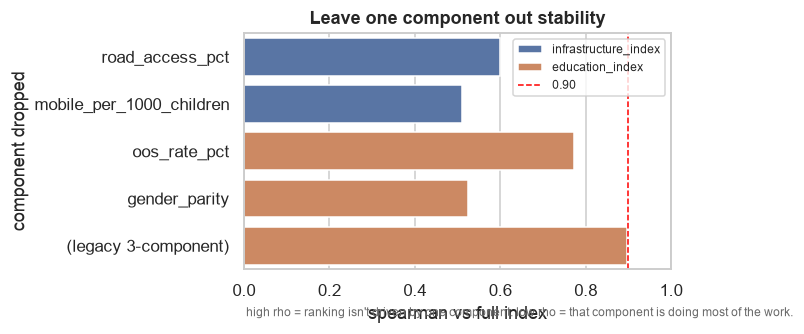

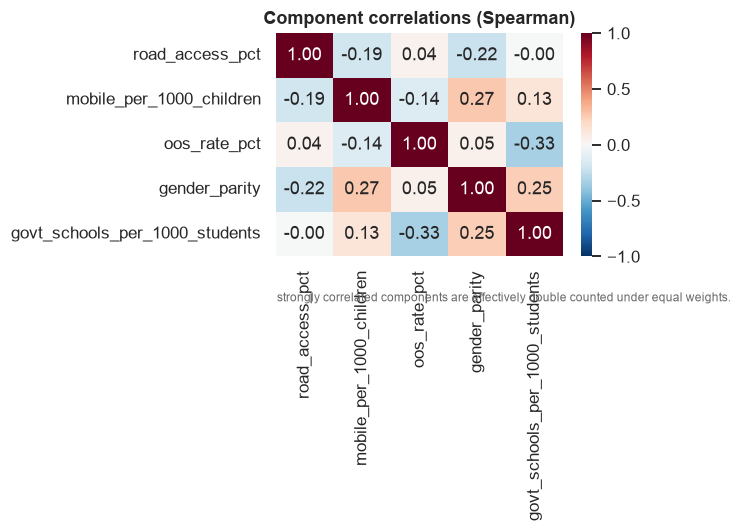

In [19]:
rows = []
for name, comps in [("infrastructure_index", INFRA_COMPONENTS),
                    ("education_index", EDU_COMPONENTS)]:
    full = comp[name]
    for drop in comps:
        keep = [f"z_{c}" for c in comps if c != drop]
        alt = comp[keep].mean(axis=1)
        m = full.notna() & alt.notna()
        rho = stats.spearmanr(full[m], alt[m]).statistic
        rows.append({"index": name, "component dropped": drop,
                     "spearman vs full index": rho})
m = comp["education_index"].notna() & comp["education_index_legacy"].notna()
rows.append({"index": "education_index", "component dropped": "(legacy 3-component)",
             "spearman vs full index": stats.spearmanr(
                 comp.loc[m, "education_index"],
                 comp.loc[m, "education_index_legacy"]).statistic})
sens = pd.DataFrame(rows)
display(sens)

fig, ax = plt.subplots(figsize=(7, 3.2))
sns.barplot(sens, y="component dropped", x="spearman vs full index",
            hue="index", ax=ax)
ax.axvline(0.9, color="red", ls="--", lw=1, label="0.90")
ax.set_xlim(0, 1); ax.set_title("Leave one component out stability")
ax.legend(fontsize=8)
scope_note(ax, "high rho = ranking isn't driven by one component. "
               "low rho = that component is doing most of the work.")
plt.show()

corr_cols = ["road_access_pct", "mobile_per_1000_children", "oos_rate_pct",
             "gender_parity", "govt_schools_per_1000_students"]
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(idx[corr_cols].corr(method="spearman"), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Component correlations (Spearman)")
scope_note(ax, "strongly correlated components are effectively double counted "
               "under equal weights.")
plt.show()

## F - The master district table

Every primary district string picks up its parent district's index values. The two
Belagavi education districts end up with identical infrastructure and education
numbers, which G5 uses on purpose.

In [20]:
master = audit.merge(idx, left_on="parent_district", right_on="District", how="left") \
              .drop(columns="District")
master = master.merge(
    aser.rename(columns={"kag_name": "parent_district"})[
        ["parent_district", "Division", "% Can Do Subtraction (Std III-V)",
         "% Can Do Division (Std VI-VIII)", "% Not Enrolled in School (6-14)",
         "% Enrolled in Govt School (6-14)"]],
    on="parent_district", how="left")
master = master.merge(prim[["District", "mastery_all_years", "subtraction_g45",
                            "division_g6"]],
                      left_on="primary_district", right_on="District",
                      how="left").drop(columns="District")
master = master.rename(columns={
    "% Can Do Subtraction (Std III-V)": "aser_subtraction_pct",
    "% Can Do Division (Std VI-VIII)": "aser_division_pct"})

print(f"master table: {master.shape[0]} rows x {master.shape[1]} cols")
print("rows missing an infrastructure index:",
      master.loc[master['infrastructure_index'].isna(), 'primary_district'].tolist() or "none")
display(master.head())

master table: 28 rows x 26 cols
rows missing an infrastructure index: none


,primary_district,parent_district,is_education_district,in_KAG,in_ASER,partial_coverage,n_students,mastery,road_access_pct,mobile_per_1000_children,oos_rate_pct,gender_parity,govt_schools_per_1000_students,students_per_school_10_3a,infrastructure_index,education_index,education_index_legacy,edu_components_used,Division,aser_subtraction_pct,aser_division_pct,% Not Enrolled in School (6-14),% Enrolled in Govt School (6-14),mastery_all_years,subtraction_g45,division_g6
0,bagalkot,Bagalkote,False,True,True,False,34676.000,0.587,78.940,140.329,0.006,0.873,4.853,206.050,0.322,0.651,0.442,2,Belgaum,39.300,46.600,0.500,72.800,0.606,0.556,0.497
1,ballari,Ballari,False,True,True,False,18779.000,0.362,100.000,687.045,NaN,0.868,3.551,281.604,0.611,0.284,0.144,1,Kalaburagi,22.400,19.100,0.700,70.600,0.425,0.353,0.207
2,belagavi,Belagavi,False,True,True,False,30827.000,0.630,81.970,313.763,0.012,0.913,9.421,106.143,0.381,0.755,0.535,2,Belgaum,29.400,24.800,0.100,76.400,0.674,0.613,0.502
3,belagavi chikkodi,Belagavi,True,True,True,False,35795.000,0.584,81.970,313.763,0.012,0.913,9.421,106.143,0.381,0.755,0.535,2,Belgaum,29.400,24.800,0.100,76.400,0.629,0.544,0.453
4,bengaluru rural,Bengaluru (Rural),False,True,True,False,8821.000,0.616,100.000,502.908,0.109,0.997,59.567,16.788,0.577,0.908,0.901,2,Bangalore,44.700,40.800,0.000,63.100,0.608,0.607,0.412


## G - cross dataset analysis

primary mastery vs indices & ASER.

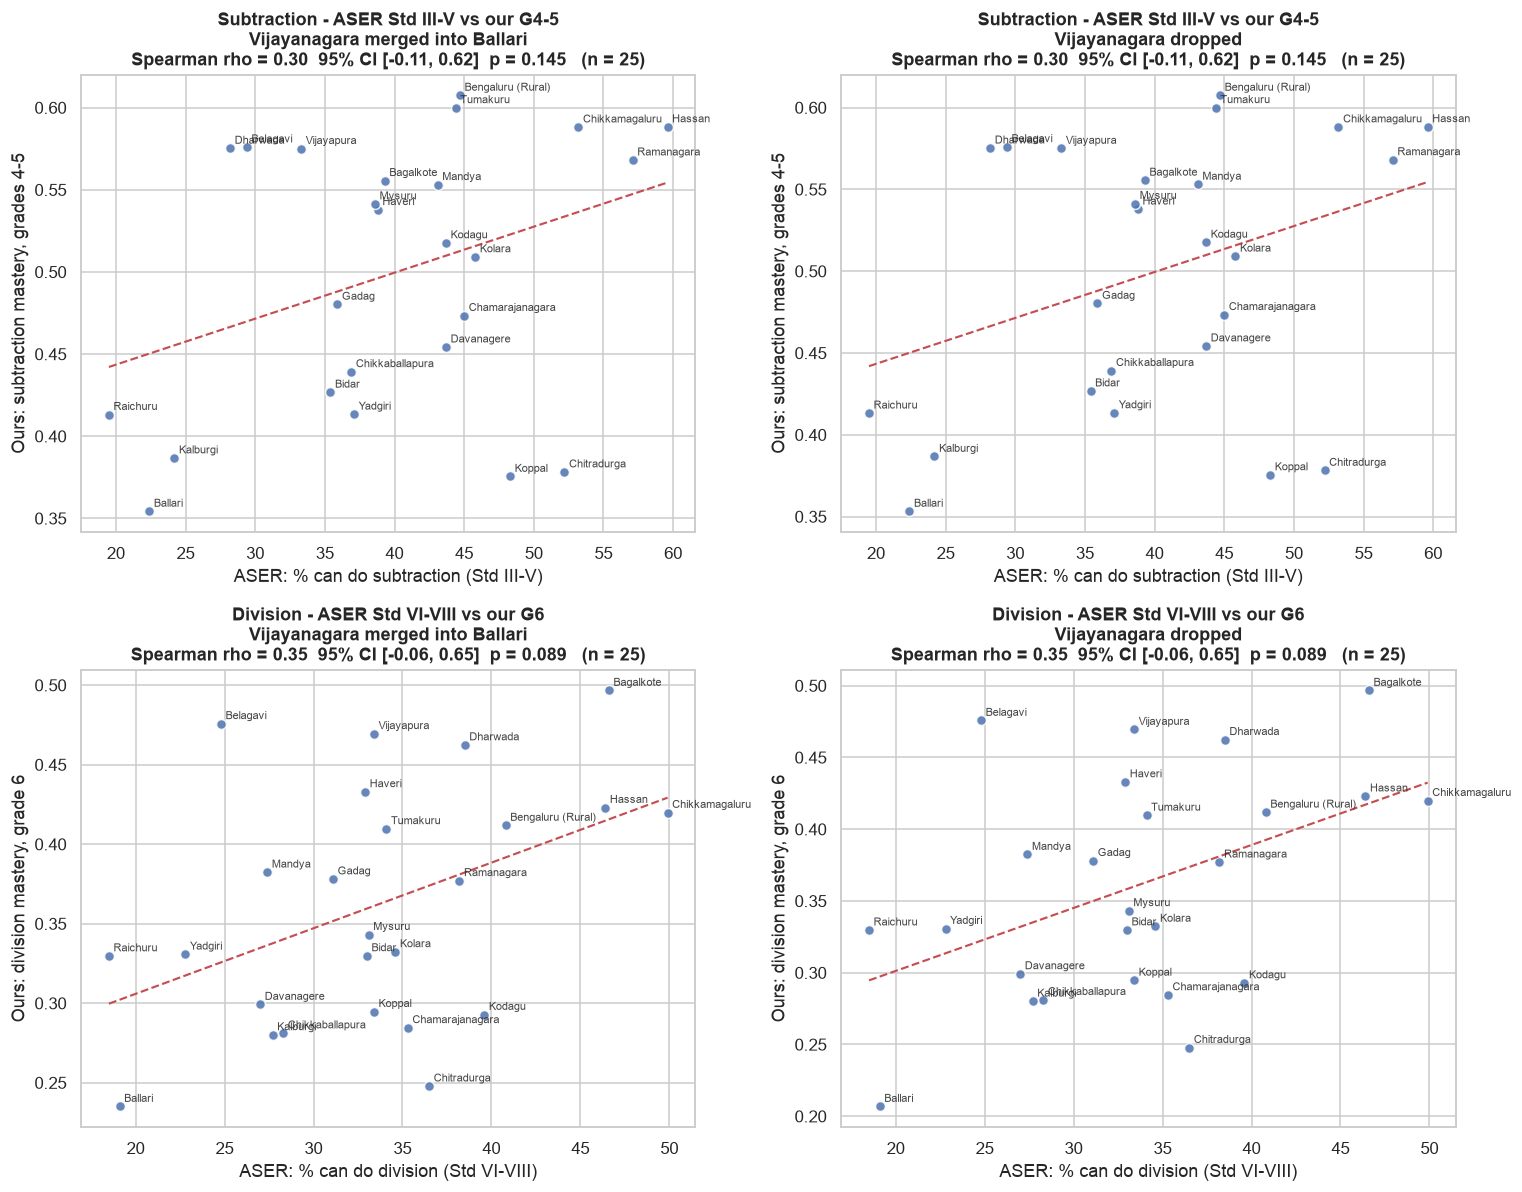

,comparison,vijayanagara,spearman,p_value,ci_low,ci_high,pearson,n
0,subtraction,merge,0.300,0.145,-0.108,0.622,0.353,25
1,division,merge,0.347,0.089,-0.056,0.653,0.437,25
2,subtraction,drop,0.300,0.145,-0.108,0.622,0.354,25
3,division,drop,0.347,0.089,-0.056,0.653,0.452,25


if rho barely moves between the two columns, the Vijayanagara choice isn't driving the result.

  subtraction  (merge): rho=0.30, p=0.145 -> inconclusive - CI includes zero
  division     (merge): rho=0.35, p=0.089 -> inconclusive - CI includes zero
  subtraction  (drop ): rho=0.30, p=0.145 -> inconclusive - CI includes zero
  division     (drop ): rho=0.35, p=0.089 -> inconclusive - CI includes zero

with ~25 districts this test has low power - a null result doesn't mean the data disagree, just that this comparison can't settle it.


In [21]:
def aser_frame(handling):
    #'merge' folds Vijayanagara into Ballari, 'drop' removes it
    d = master.dropna(subset=["parent_district"]).copy()
    d = (d.groupby("parent_district", observed=True)
           .apply(lambda x: pd.Series({
               "mastery": wavg(x, "mastery", "n_students"),
               "subtraction_g45": wavg(x, "subtraction_g45", "n_students"),
               "division_g6": wavg(x, "division_g6", "n_students"),
               "n_students": x["n_students"].sum(),
               "infrastructure_index": x["infrastructure_index"].max(),
               "education_index": x["education_index"].max()}))
           .reset_index())
    if handling == "merge":
        d["join_key"] = d["parent_district"].replace({"Vijayanagara": "Ballari"})
        d = (d.groupby("join_key", observed=True)
               .apply(lambda x: pd.Series({
                   "mastery": wavg(x, "mastery", "n_students"),
                   "subtraction_g45": wavg(x, "subtraction_g45", "n_students"),
                   "division_g6": wavg(x, "division_g6", "n_students"),
                   "n_students": x["n_students"].sum()}))
               .reset_index().rename(columns={"join_key": "parent_district"}))
    else:
        d = d[d["parent_district"] != "Vijayanagara"]
    return d.merge(aser.rename(columns={"kag_name": "parent_district"})[
        ["parent_district", "% Can Do Subtraction (Std III-V)",
         "% Can Do Division (Std VI-VIII)"]].rename(columns={
             "% Can Do Subtraction (Std III-V)": "aser_subtraction_pct",
             "% Can Do Division (Std VI-VIII)": "aser_division_pct"}),
        on="parent_district", how="inner")

def agreement_panel(ax, d, xcol, ycol, title):
    m = d[xcol].notna() & d[ycol].notna()
    x, y = d.loc[m, xcol], d.loc[m, ycol]
    if len(x) < 3:
        ax.text(.5, .5, "not enough overlapping districts", ha="center")
        return np.nan, np.nan, 0
    sp  = stats.spearmanr(x, y)
    rho, pval = sp.statistic, sp.pvalue
    r   = stats.pearsonr(x, y).statistic
    z, se = np.arctanh(np.clip(rho, -.999, .999)), 1 / np.sqrt(len(x) - 3)
    lo, hi = np.tanh(z - 1.96 * se), np.tanh(z + 1.96 * se)
    ax.scatter(x, y, s=42, color="#4c72b0", alpha=.85, edgecolor="white")
    label_points(ax, x, y, d.loc[m, "parent_district"])
    b, a = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 20)
    ax.plot(xs, a + b * xs, color="#c44e52", lw=1.4, ls="--")
    ax.set_title(f"{title}\nSpearman rho = {rho:.2f}  95% CI [{lo:.2f}, {hi:.2f}]  "
                 f"p = {pval:.3f}   (n = {len(x)})")
    return rho, r, len(x), pval, lo, hi

results = []
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for col, handling in enumerate(["merge", "drop"]):
    d = aser_frame(handling)
    tag = ("Vijayanagara merged into Ballari" if handling == "merge"
           else "Vijayanagara dropped")
    rho1, r1, n1, p1, lo1, hi1 = agreement_panel(
        axes[0, col], d, "aser_subtraction_pct", "subtraction_g45",
        f"Subtraction - ASER Std III-V vs our G4-5\n{tag}")
    axes[0, col].set_xlabel("ASER: % can do subtraction (Std III-V)")
    axes[0, col].set_ylabel("Ours: subtraction mastery, grades 4-5")
    rho2, r2, n2, p2, lo2, hi2 = agreement_panel(
        axes[1, col], d, "aser_division_pct", "division_g6",
        f"Division - ASER Std VI-VIII vs our G6\n{tag}")
    axes[1, col].set_xlabel("ASER: % can do division (Std VI-VIII)")
    axes[1, col].set_ylabel("Ours: division mastery, grade 6")
    results += [{"comparison": "subtraction", "vijayanagara": handling,
                 "spearman": rho1, "p_value": p1, "ci_low": lo1, "ci_high": hi1,
                 "pearson": r1, "n": n1},
                {"comparison": "division", "vijayanagara": handling,
                 "spearman": rho2, "p_value": p2, "ci_low": lo2, "ci_high": hi2,
                 "pearson": r2, "n": n2}]
plt.show()

agree = pd.DataFrame(results)
display(agree)
print("if rho barely moves between the two columns, the Vijayanagara choice isn't "
      "driving the result.\n")

for _, row in agree.iterrows():
    if row["p_value"] < 0.05:
        verdict = "distinguishable from chance"
    elif row["ci_low"] < 0 < row["ci_high"]:
        verdict = "inconclusive - CI includes zero"
    else:
        verdict = "weak, borderline"
    print(f"  {row['comparison']:12s} ({row['vijayanagara']:5s}): "
          f"rho={row['spearman']:.2f}, p={row['p_value']:.3f} -> {verdict}")
print("\nwith ~25 districts this test has low power - a null result doesn't mean "
      "the data disagree, just that this comparison can't settle it.")

> _TODO: interpret - the claim to make is about rank agreement, not levels._

### G2 - infrastructure isn't the binding constraint

Quadrant plot, split on the medians. The interesting corner is high infrastructure /
low mastery - districts with the roads and connectivity that still aren't converting
it into arithmetic. More infrastructure spending isn't the lever for those.

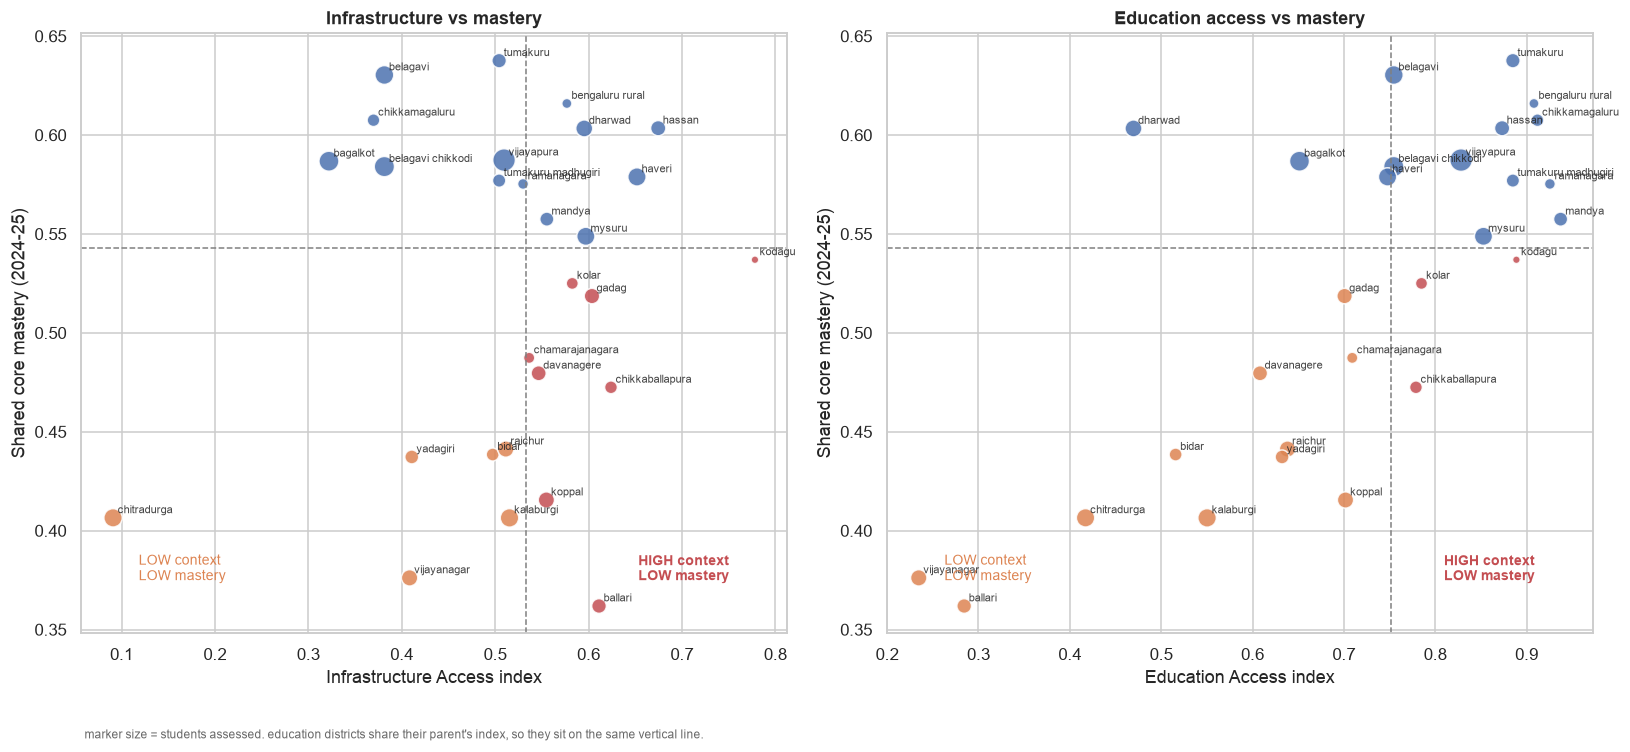

HIGH infrastructure / LOW mastery: ['ballari', 'chamarajanagara', 'chikkaballapura', 'davanagere', 'gadag', 'kodagu', 'kolar', 'koppal']
HIGH education access / LOW mastery: ['chikkaballapura', 'kodagu', 'kolar']
in both: ['chikkaballapura', 'kodagu', 'kolar']


In [22]:
def quadrant(ax, d, xcol, ycol, xlabel, ylabel, title):
    x, y = d[xcol], d[ycol]
    xm, ym = x.median(), y.median()
    hi_lo = (x >= xm) & (y < ym)
    lo_lo = (x < xm) & (y < ym)
    colours = np.where(hi_lo, "#c44e52", np.where(lo_lo, "#dd8452", "#4c72b0"))
    ax.scatter(x, y, s=np.clip(d["n_students"] / d["n_students"].max() * 220, 25, 220),
               c=colours, alpha=.85, edgecolor="white")
    label_points(ax, x, y, d["primary_district"])
    ax.axvline(xm, color="grey", ls="--", lw=1)
    ax.axhline(ym, color="grey", ls="--", lw=1)
    pad_x = (x.max() - x.min()) * .04
    pad_y = (y.max() - y.min()) * .04
    ax.text(x.max() - pad_x, y.min() + pad_y, "HIGH context\nLOW mastery",
            ha="right", va="bottom", fontsize=9, color="#c44e52", weight="bold")
    ax.text(x.min() + pad_x, y.min() + pad_y, "LOW context\nLOW mastery",
            ha="left", va="bottom", fontsize=9, color="#dd8452")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    return d.loc[hi_lo, "primary_district"].tolist()

plot_df = master.dropna(subset=["infrastructure_index", "education_index", "mastery"])

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
hi_infra_lo = quadrant(axes[0], plot_df, "infrastructure_index", "mastery",
                       "Infrastructure Access index",
                       f"Shared core mastery ({FOCUS_YEAR})",
                       "Infrastructure vs mastery")
hi_edu_lo = quadrant(axes[1], plot_df, "education_index", "mastery",
                     "Education Access index",
                     f"Shared core mastery ({FOCUS_YEAR})",
                     "Education access vs mastery")
scope_note(axes[0], "marker size = students assessed. education districts share "
                    "their parent's index, so they sit on the same vertical line.")
plt.show()

print("HIGH infrastructure / LOW mastery:", hi_infra_lo)
print("HIGH education access / LOW mastery:", hi_edu_lo)
print("in both:", sorted(set(hi_infra_lo) & set(hi_edu_lo)))

> _TODO: interpret - name the districts in the red quadrant, that list is the headline._

### G3 - does this hold up with a different index?

Before reading much into the correlations, check whether they're about the districts
or about how the index happens to be built. Each component gets tested on its own,
alongside the composite, plus the two component Education Access index against the
legacy three component one.

### G3a - how much does context even explain?

A plain correlation panel first, then the model. With ~29 parent districts this is a
descriptive exercise - the point isn't prediction, it's how much of the district
pattern context accounts for, and therefore how much it doesn't.

In [23]:
ALT = {"infrastructure_index": "Infrastructure Access (2 components)",
       "road_access_pct": "road access alone",
       "mobile_per_1000_children": "mobile per 1,000 children alone",
       "education_index": "Education Access (2 components, no schools ratio)",
       "education_index_legacy": "Education Access LEGACY (with broken schools ratio)",
       "oos_rate_pct": "out of school rate alone (expect negative)",
       "gender_parity": "enrolment gender parity alone"}

robust_rows = []
print("does the headline depend on how the index was built?\n")
print(f"{'measure':54s} {'rho':>7} {'p':>7} {'n':>4}")
for c, lab in ALT.items():
    m = master[["mastery", c]].dropna()
    sp = stats.spearmanr(m["mastery"], m[c])
    z, se = np.arctanh(np.clip(sp.statistic, -.999, .999)), 1 / np.sqrt(len(m) - 3)
    robust_rows.append({"measure": c, "label": lab, "rho": sp.statistic,
                        "p": sp.pvalue, "ci_low": np.tanh(z - 1.96 * se),
                        "ci_high": np.tanh(z + 1.96 * se), "n": len(m)})
    star = " *" if sp.pvalue < 0.05 else ""
    print(f"{lab:54s} {sp.statistic:>+7.3f} {sp.pvalue:>7.3f} {len(m):>4}{star}")
robust = pd.DataFrame(robust_rows)
print("\nread the two Education Access rows together - if only the LEGACY version is "
      "significant, that means the schools ratio was driving it, and that's the "
      "component our own check flagged as unusable.")

does the headline depend on how the index was built?

measure                                                    rho       p    n
Infrastructure Access (2 components)                    -0.038   0.850   28
road access alone                                       -0.018   0.928   28
mobile per 1,000 children alone                         -0.037   0.852   28
Education Access (2 components, no schools ratio)       +0.652   0.000   28 *
Education Access LEGACY (with broken schools ratio)     +0.553   0.002   28 *
out of school rate alone (expect negative)              -0.571   0.003   25 *
enrolment gender parity alone                           +0.289   0.135   28

read the two Education Access rows together - if only the LEGACY version is significant, that means the schools ratio was driving it, and that's the component our own check flagged as unusable.


### G3b - correlations

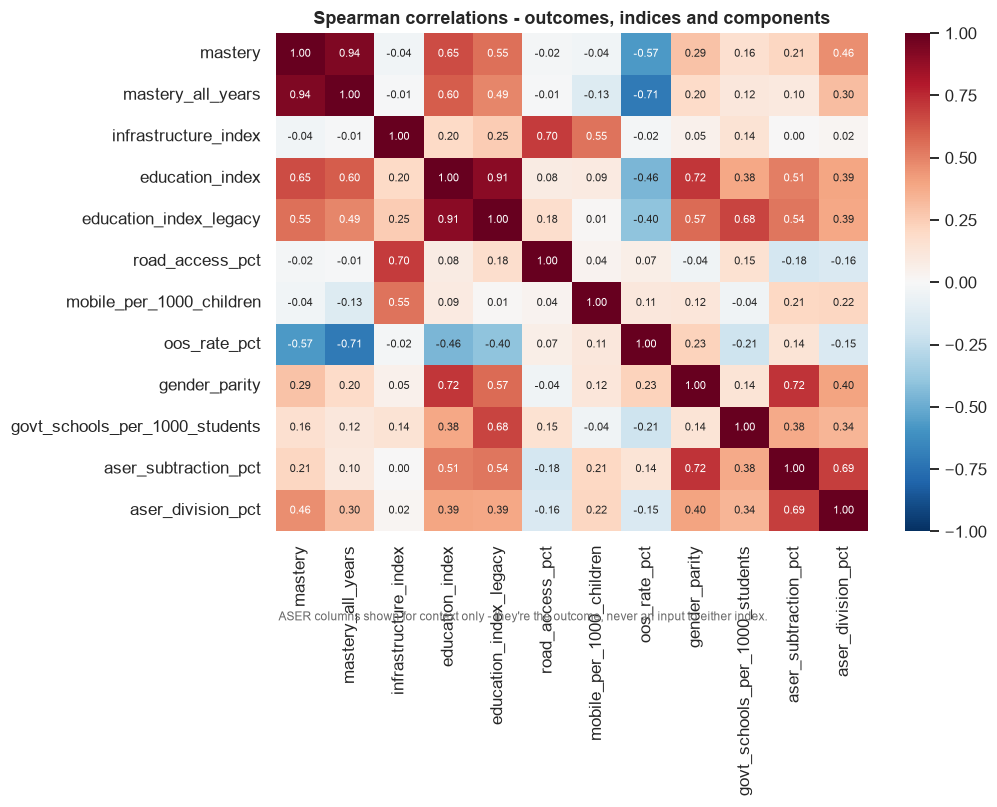

mastery vs each index (Spearman, n excludes missing):
  infrastructure_index     rho = -0.038  p = 0.850  n = 28
  education_index          rho = +0.652  p = 0.000  n = 28


In [24]:
corr_vars = ["mastery", "mastery_all_years", "infrastructure_index", "education_index",
             "education_index_legacy",
             "road_access_pct", "mobile_per_1000_children", "oos_rate_pct",
             "gender_parity", "govt_schools_per_1000_students",
             "aser_subtraction_pct", "aser_division_pct"]
cm = master[corr_vars].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9.5, 7.5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            ax=ax, annot_kws={"size": 7})
ax.set_title("Spearman correlations - outcomes, indices and components")
scope_note(ax, "ASER columns shown for context only - they're the outcome, "
               "never an input to either index.")
plt.show()

print("mastery vs each index (Spearman, n excludes missing):")
for c in ["infrastructure_index", "education_index"]:
    m = master[["mastery", c]].dropna()
    rho = stats.spearmanr(m["mastery"], m[c]).statistic
    p = stats.spearmanr(m["mastery"], m[c]).pvalue
    print(f"  {c:24s} rho = {rho:+.3f}  p = {p:.3f}  n = {len(m)}")

### G4 - the residual

Fit mastery on the two indices, then look at what the model misses.

- **Large negative residual** -> the district underperforms its own context. That's
  an audit question, not a funding one - the resources are there and the outcome
  isn't.
- **Large positive residual** -> it outperforms districts with similar context.
  Worth studying and replicating.

This is descriptive, not causal, on ~29 districts. Think of the residual as a way to
rank which questions to ask, not a measurement of district effort.

mastery = 0.318 + -0.072*infrastructure +0.339*education
R2 = 0.558   adjusted R2 = 0.523   n = 28
-> context explains 56% of the district level spread; 44% is something else.


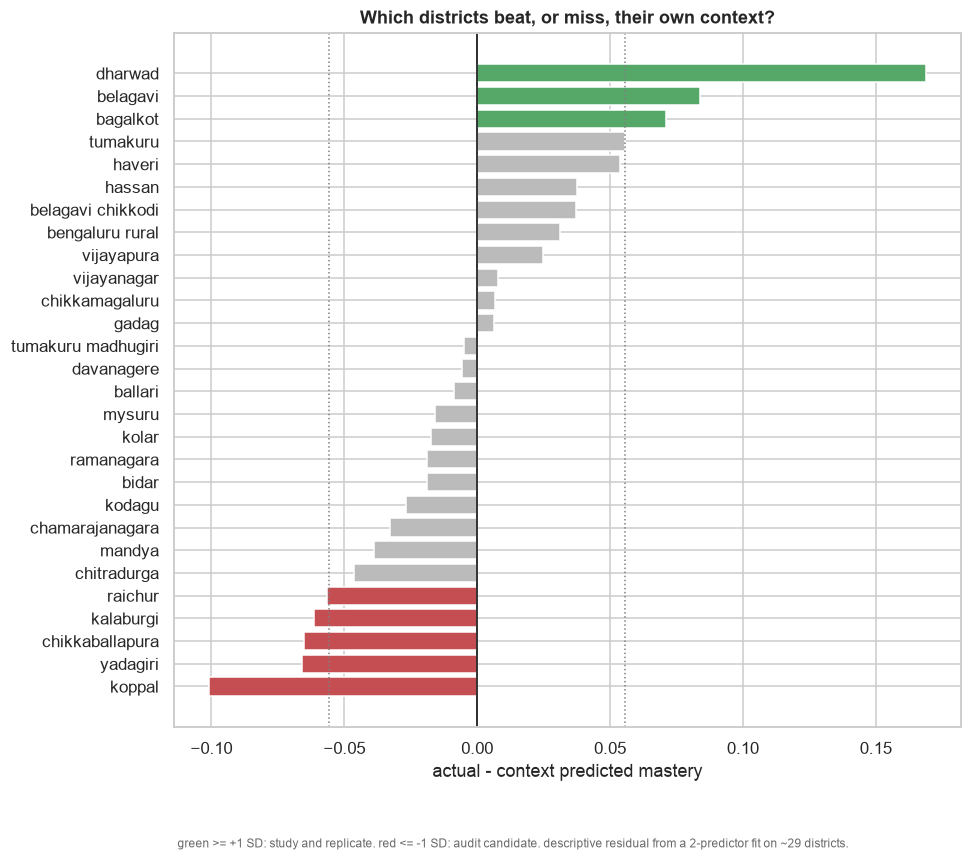

,primary_district,parent_district,mastery,predicted_mastery,residual,residual_sd,infrastructure_index,education_index
18,koppal,Koppal,0.415,0.516,-0.101,-1.812,0.555,0.702
27,yadagiri,Yadgiri,0.437,0.503,-0.066,-1.183,0.411,0.632
7,chikkaballapura,Chikkaballapura,0.472,0.537,-0.065,-1.169,0.624,0.779
15,kalaburgi,Kalburgi,0.406,0.468,-0.061,-1.101,0.515,0.550
21,raichur,Raichuru,0.441,0.498,-0.057,-1.018,0.511,0.638
9,chitradurga,Chitradurga,0.406,0.453,-0.047,-0.836,0.091,0.417


,primary_district,mastery,predicted_mastery,residual,residual_sd
11,dharwad,0.603,0.435,0.169,3.033
2,belagavi,0.630,0.547,0.084,1.504
0,bagalkot,0.587,0.516,0.071,1.274
23,tumakuru,0.638,0.582,0.056,0.998
14,haveri,0.579,0.525,0.054,0.969
13,hassan,0.603,0.566,0.038,0.676


In [25]:
fit = master.dropna(subset=["mastery", "infrastructure_index", "education_index"]).copy()
X = np.column_stack([np.ones(len(fit)), fit["infrastructure_index"],
                     fit["education_index"]])
y = fit["mastery"].values
beta, *_ = np.linalg.lstsq(X, y, rcond=None)
pred = X @ beta
resid = y - pred
ss_res, ss_tot = (resid ** 2).sum(), ((y - y.mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot
adj = 1 - (1 - r2) * (len(y) - 1) / (len(y) - 2 - 1)

fit["predicted_mastery"] = pred
fit["residual"] = resid
fit["residual_sd"] = resid / resid.std(ddof=1)

print(f"mastery = {beta[0]:.3f} + {beta[1]:+.3f}*infrastructure "
      f"{beta[2]:+.3f}*education")
print(f"R2 = {r2:.3f}   adjusted R2 = {adj:.3f}   n = {len(y)}")
print(f"-> context explains {r2*100:.0f}% of the district level spread; "
      f"{100-r2*100:.0f}% is something else.")
if r2 < 0.10:
    print("\nR2 is low here - context barely predicts mastery, so the residual "
          "below is close to mastery just re centred. Still a finding (infrastructure "
          "and access aren't the binding constraint), just not a context adjusted score.")

fig, ax = plt.subplots(figsize=(9, 8))
d = fit.sort_values("residual")
colours = np.where(d["residual_sd"] <= -1, "#c44e52",
                   np.where(d["residual_sd"] >= 1, "#55a868", "#bbbbbb"))
ax.barh(d["primary_district"], d["residual"], color=colours)
ax.axvline(0, color="black", lw=1)
for s, ls in [(1, ":"), (-1, ":")]:
    ax.axvline(s * resid.std(ddof=1), color="grey", ls=ls, lw=1)
ax.set_xlabel("actual - context predicted mastery")
ax.set_title("Which districts beat, or miss, their own context?")
scope_note(ax, "green >= +1 SD: study and replicate. red <= -1 SD: audit candidate. "
               "descriptive residual from a 2-predictor fit on ~29 districts.")
plt.show()

display(fit[["primary_district", "parent_district", "mastery", "predicted_mastery",
             "residual", "residual_sd", "infrastructure_index", "education_index"]]
        .sort_values("residual").head(6))
display(fit[["primary_district", "mastery", "predicted_mastery", "residual",
             "residual_sd"]].sort_values("residual", ascending=False).head(6))

> _TODO: interpret - name the audit candidates and the positive outliers._

### G5 - within context contrast

Belagavi and Chikkodi are two education districts of one revenue district, so they
share every index value here by construction. Any mastery gap between them can't be
explained by district level infrastructure or education access - it's administrative,
or it's below district level.

Useful as a check on how far district level targeting can actually go, and it lines
up with the variance decomposition point from notebook 01.

revenue districts split across education districts: ['Belagavi', 'Tumakuru']


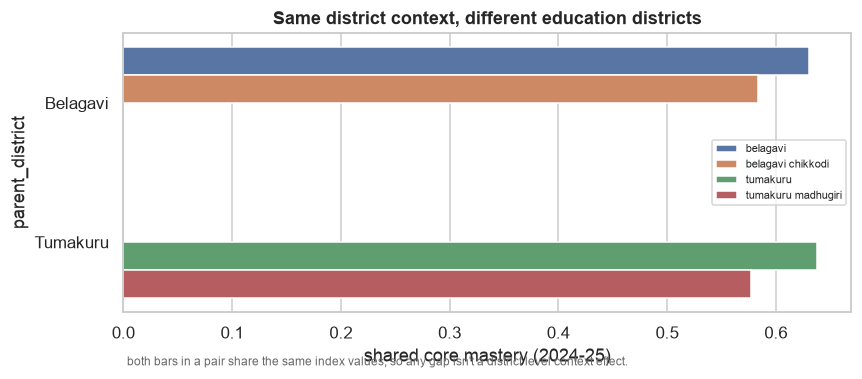

,min,max,gap
parent_district,,,
Tumakuru,0.577,0.638,0.061
Belagavi,0.584,0.630,0.046


largest within district gap: 0.061 mastery points - compare to the between district spread of 0.276.


In [26]:
pairs = master.dropna(subset=["parent_district"]).copy()
grp = pairs.groupby("parent_district")["primary_district"].nunique()
split_parents = grp[grp > 1].index.tolist()
print("revenue districts split across education districts:", split_parents or "none")
pair_gap = pd.DataFrame(columns=["parent_district", "min", "max", "gap"])

if split_parents:
    sp = pairs[pairs["parent_district"].isin(split_parents)].copy()
    fig, ax = plt.subplots(figsize=(8, 3.6))
    sns.barplot(sp, y="parent_district", x="mastery", hue="primary_district", ax=ax)
    ax.set_xlabel(f"shared core mastery ({FOCUS_YEAR})")
    ax.set_title("Same district context, different education districts")
    ax.legend(fontsize=7, title=None)
    scope_note(ax, "both bars in a pair share the same index values, so any gap "
                   "isn't a district level context effect.")
    plt.show()
    gap = (sp.groupby("parent_district")["mastery"].agg(["min", "max"])
             .assign(gap=lambda d: d["max"] - d["min"])
             .sort_values("gap", ascending=False))
    pair_gap = gap.reset_index()
    display(gap)
    print(f"largest within district gap: {gap['gap'].max():.3f} mastery points - "
          f"compare to the between district spread of "
          f"{master['mastery'].max() - master['mastery'].min():.3f}.")

> _TODO: interpret - if the within district gap is close to the between district spread, district level targeting matters less than it looks._

## H - exports

In [27]:
# everything the report, slides and dashboard read from

comp_state = (focus.groupby("competency", observed=True)
              .apply(lambda d: wavg(d, "mastery_rate", "n_students"))
              .rename("mastery").reset_index().sort_values("mastery"))
comp_district = (focus.groupby(["District", "competency"], observed=True)
                 .apply(lambda d: wavg(d, "mastery_rate", "n_students"))
                 .rename("mastery_rate").reset_index())
comp_spread = (comp_district.groupby("competency")["mastery_rate"]
               .agg(["mean", "std", "min", "max"]).reset_index()
               .assign(spread=lambda d: d["max"] - d["min"])
               .sort_values("mean"))

tables = {
    "district_indices.csv": idx,
    "district_master_table.csv": master,
    "district_join_audit.csv": audit,
    "index_sensitivity.csv": sens,
    "index_robustness.csv": robust,
    "index_components_full.csv": comp,
    "aser_agreement.csv": agree,
    "context_residuals.csv": fit[["primary_district", "parent_district", "mastery",
                                  "predicted_mastery", "residual", "residual_sd",
                                  "infrastructure_index", "education_index"]],
    "district_coverage_by_year.csv": cov_year.reset_index(),
    "district_mastery_focus_year.csv": prim,
    "competency_mastery_state.csv": comp_state,
    "competency_spread.csv": comp_spread,
    "competency_mastery_by_district.csv": comp_district,
    "education_district_pairs.csv": pair_gap,
}
for name, table in tables.items():
    table.to_csv(OUT / name, index=False)

# headline numbers in one place so nothing has to be retyped into the report
headline = {
    "focus_year": FOCUS_YEAR,
    "core_competencies": CORE,
    "n_core": len(CORE),
    "n_district_strings": int(len(audit)),
    "n_parent_districts": int(audit["parent_district"].nunique()),
    "n_years": int(mastery["Year"].nunique()),
    "districts_every_year": int(len(common)),
    "districts_union": int(len(all_d)),
    "kag_without_primary": sorted(kag_names - set(audit["parent_district"].dropna())),
    "unmapped": unmapped,
    "state_mastery": float(wavg(focus, "mastery_rate", "n_students")),
    "weakest_competency": str(comp_state.iloc[0]["competency"]),
    "weakest_competency_mastery": float(comp_state.iloc[0]["mastery"]),
    "strongest_competency": str(comp_state.iloc[-1]["competency"]),
    "strongest_competency_mastery": float(comp_state.iloc[-1]["mastery"]),
    "best_district": str(prim.iloc[0]["District"]),
    "best_district_mastery": float(prim["mastery"].max()),
    "worst_district": str(prim.iloc[-1]["District"]),
    "worst_district_mastery": float(prim["mastery"].min()),
    "district_spread": float(prim["mastery"].max() - prim["mastery"].min()),
    "infra_rho": float(robust.loc[robust["measure"] == "infrastructure_index", "rho"].iloc[0]),
    "infra_p": float(robust.loc[robust["measure"] == "infrastructure_index", "p"].iloc[0]),
    "edu_rho": float(robust.loc[robust["measure"] == "education_index", "rho"].iloc[0]),
    "edu_p": float(robust.loc[robust["measure"] == "education_index", "p"].iloc[0]),
    "edu_legacy_rho": float(robust.loc[robust["measure"] == "education_index_legacy", "rho"].iloc[0]),
    "edu_legacy_p": float(robust.loc[robust["measure"] == "education_index_legacy", "p"].iloc[0]),
    "r2": float(r2),
    "n_fit": int(len(fit)),
    "aser_conclusive": bool((agree["p_value"] < 0.05).any()),
    "aser_best_rho": float(agree["spearman"].max()),
    "aser_min_p": float(agree["p_value"].min()),
    "aser_n": int(agree["n"].max()),
    "hi_infra_lo": hi_infra_lo,
    "hi_edu_lo": hi_edu_lo,
    "audit_candidates": fit.nsmallest(5, "residual")["primary_district"].tolist(),
    "replicate_candidates": fit.nlargest(5, "residual")["primary_district"].tolist(),
    "max_pair_gap": float(pair_gap["gap"].max()) if len(pair_gap) else None,
    "pair_parents": pair_gap["parent_district"].tolist() if len(pair_gap) else [],
    "students_per_school_min": float(comp["students_per_school_10_3a"].min()),
    "students_per_school_max": float(comp["students_per_school_10_3a"].max()),
}
with open(OUT / "headline_numbers.json", "w") as fh:
    json.dump(headline, fh, indent=2)

print(f"{len(tables)} tables written to {OUT}/")
for name in sorted(tables):
    print(f"  {name:38s} {len(tables[name]):>7,} rows")
print(f"\n{len(sorted(FIG.glob('*.png')))} figures in {FIG}/")
print("headline_numbers.json written - every number the write up needs, in one file")

14 tables written to outputs/
  aser_agreement.csv                           4 rows
  competency_mastery_by_district.csv         196 rows
  competency_mastery_state.csv                 7 rows
  competency_spread.csv                        7 rows
  context_residuals.csv                       28 rows
  district_coverage_by_year.csv                3 rows
  district_indices.csv                        31 rows
  district_join_audit.csv                     28 rows
  district_master_table.csv                   28 rows
  district_mastery_focus_year.csv             28 rows
  education_district_pairs.csv                 2 rows
  index_components_full.csv                   31 rows
  index_robustness.csv                         7 rows
  index_sensitivity.csv                        5 rows

982 figures in outputs/figures/
headline_numbers.json written - every number the write up needs, in one file


### Manifest entries for these two sources

```yaml
- name: Karnataka At A Glance 2024-25
  publisher: Directorate of Economics & Statistics, Planning Programme Monitoring
             & Statistics Department, Government of Karnataka
  tables: [9.3a, 9.4, 10.3a, 10.4a, 10.5a, 10.8]
  level: district
  notes: >
    Extracted from a scanned PDF by OCR with manual verification; every sheet carries a
    row summing the 31 districts against the published total. Internet Connections
    excluded as implausible; Dropout Ratio excluded as identical to the computed
    out of school rate.
- name: ASER 2024 Karnataka Rural
  publisher: ASER Centre / Pratham
  level: district (30 of 31; Vijayanagara not reported separately)
  use: external validation of district ranking only — never an index input
```